In [158]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter
from collections import Counter

In [159]:
from scipy.optimize import curve_fit
def power_law(x,A,B):
    return A*x**B
def exp_law(x,A,B,C):
    return A*np.exp(-B*x)+C
def fit(dat,X):
    params_power_law , cov_power_law = curve_fit(power_law, X, dat)
    #a_power_law, b_power_law = params_power_law
    params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)

    print(np.sqrt(np.diag(cov_power_law)))
    print(np.sqrt(np.diag(cov_exp_law)))
    return params_power_law, params_exp_law



In [160]:
L =100
k=kb.k_vals(L)

U_0 = kb.U(k,2)



In [161]:
import numpy as np
from scipy.integrate import solve_ivp

def g(t, tau,g0,gf):
    return max(g0 + (gf - g0) * t / tau,0)


def rhs(t, v, k,tau,g0,gf): 
  #  print(g(t,tau))
    return [
        2 * ((g(t,tau,g0,gf) - np.cos(k)) * v[0] + np.sin(k) * v[1]) / 1j,
        2 * (-(g(t,tau,g0,gf) - np.cos(k)) * v[1] + np.sin(k) * v[0]) / 1j
    ]

from joblib import Parallel, delayed

def evolve_mode(i, v_0, k, t_span, t_eval, tau,g0,gf):
    v0 = [v_0[0][i] + 0j, v_0[1][i] + 0j]
    ki = k[i]
    res = solve_ivp(rhs, t_span, v0, args=(ki, tau,g0,gf), t_eval=t_eval)
    return res.y[0][-1], res.y[1][-1]

def evolve_mode(i, v_0, k, t_span, t_eval, tau, g0, gf):
    v0 = [v_0[0][i] + 0j, v_0[1][i] + 0j]
    ki = k[i]
    res = solve_ivp(rhs, t_span, v0, args=(ki, tau, g0, gf), t_eval=t_eval)
    return res.y  # shape: (2, len(t_eval)) → [u_k(t), v_k(t)]

   


In [129]:
L = 100
g0 = 100
gf = 0
k = kb.k_vals(L)
v_0 = kb.U(k, g0)
taus = np.logspace(-4, 2, 50)
t_eval = np.linspace(0, 2 * taus[-1], 100)  # fixed time grid

from tqdm import tqdm
from joblib import Parallel, delayed
import numpy as np

def g(t, tau, g0, gf):
    return max(g0 + (gf - g0) * t / tau, 0)

def rhs(t, v, k, tau, g0, gf):
    return [
        2 * ((g(t, tau, g0, gf) - np.cos(k)) * v[0] + np.sin(k) * v[1]) / 1j,
        2 * (-(g(t, tau, g0, gf) - np.cos(k)) * v[1] + np.sin(k) * v[0]) / 1j
    ]

def evolve_mode_all_times(i, v_0, k, t_span, t_eval, tau, g0, gf):
    v0 = [v_0[0][i] + 0j, v_0[1][i] + 0j]
    ki = k[i]
    res = solve_ivp(rhs, t_span, v0, args=(ki, tau, g0, gf), t_eval=t_eval)
    return res.y  # shape: (2, len(t_eval))

# Storage array: (tau_index, time_index, 2, L)
x = np.empty((len(taus), 2, L), dtype=complex)

for j, tau in enumerate(tqdm(taus)):
    t_span = (0, 2 * tau)
    t_eval = np.linspace(*t_span, 100)  # time points to integrate over

    results = Parallel(n_jobs=-1)(
        delayed(evolve_mode_all_times)(i, v_0, k, t_span, t_eval, tau, g0, gf)
        for i in range(L)
    )

    results = np.array(results)  # shape: (L, 2, len(t_eval))
    final_uv = results[:, :, -1].T  # shape: (2, L)
    x[j] = final_uv




100%|██████████| 50/50 [00:14<00:00,  3.52it/s]


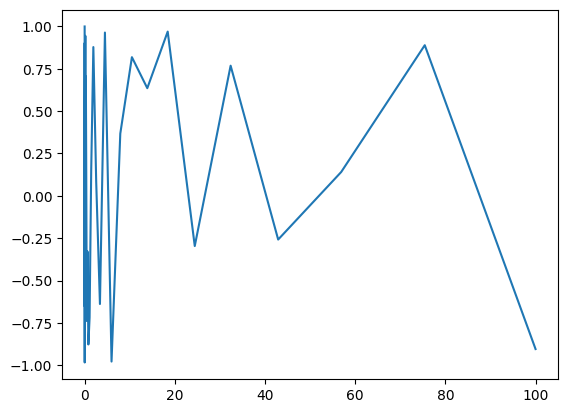

In [87]:
L = 100
k=kb.k_vals(L)
v_0 = kb.U(k,0)
taus = np.logspace(0,2,100)
x= np.empty((10,len(taus)))
from tqdm import tqdm
Uf = kb.U(k,2)
for T, tau in enumerate(tqdm(taus)):
    t_span = (0, 2*tau)
    t_eval = np.linspace(*t_span, 100)



    results = Parallel(n_jobs=-1)(
        delayed(evolve_mode)(i, v_0, k, t_span, t_eval, tau) for i in (range(len(k)))
    )
    final_time_evolve = np.array(results).T
    for j in range(10):
        x[j, T] = kb.P_n(j + 2, Uf, k) - kb.P_n(j + 2, final_time_evolve, k)


  0%|          | 0/100 [00:00<?, ?it/s]


TypeError: evolve_mode() missing 2 required positional arguments: 'g0' and 'gf'

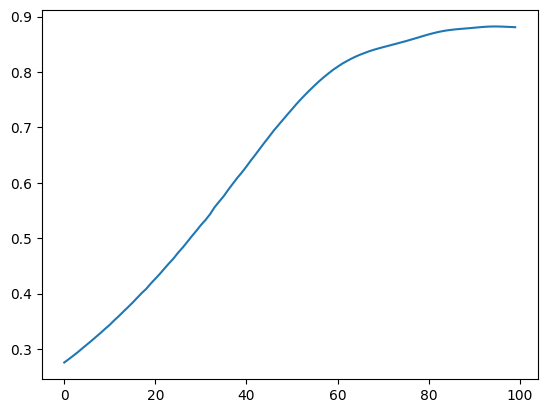

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_17058/1796649811.py:9: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-B * x) + C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_17058/1796649811.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law, X, dat, maxfev=1000)


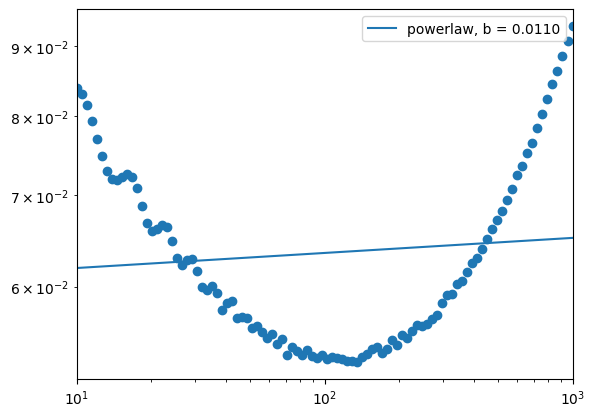

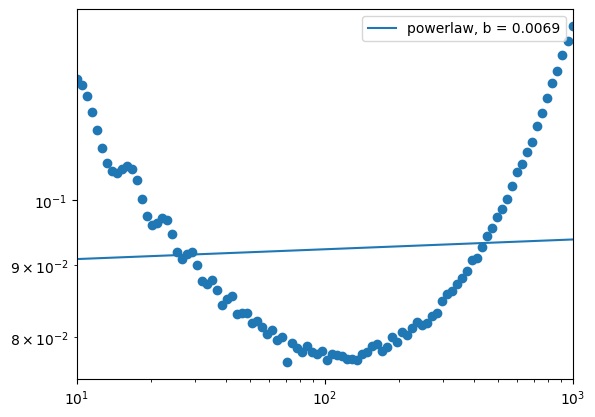

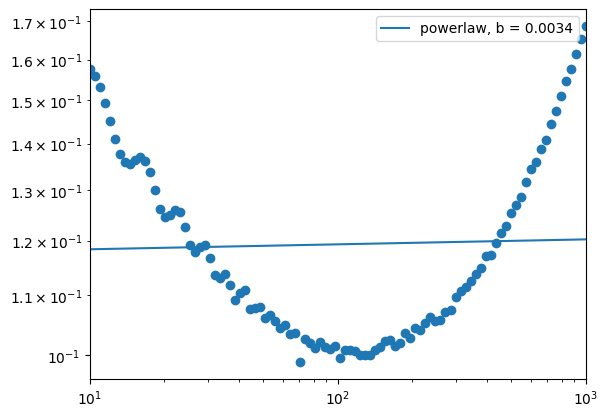

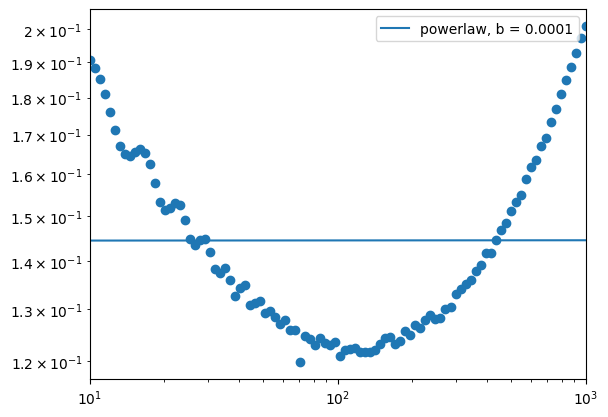

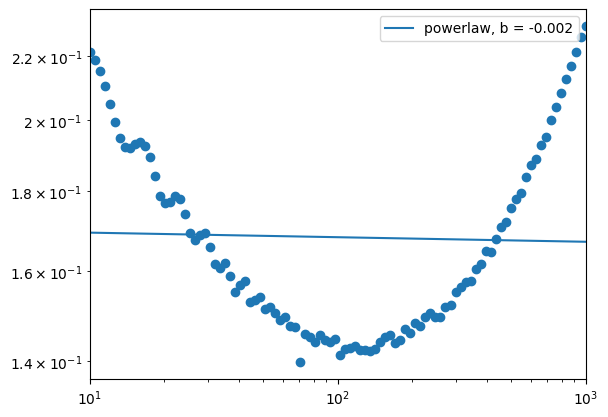

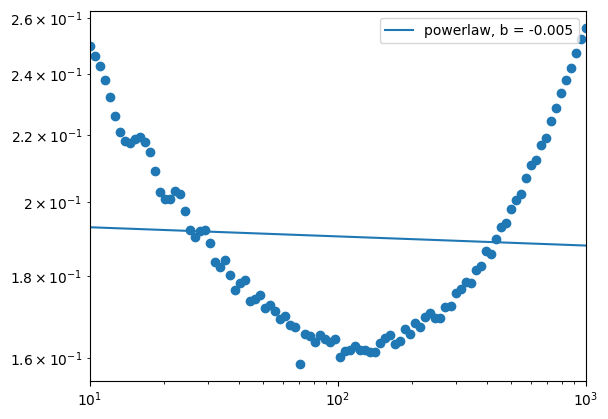

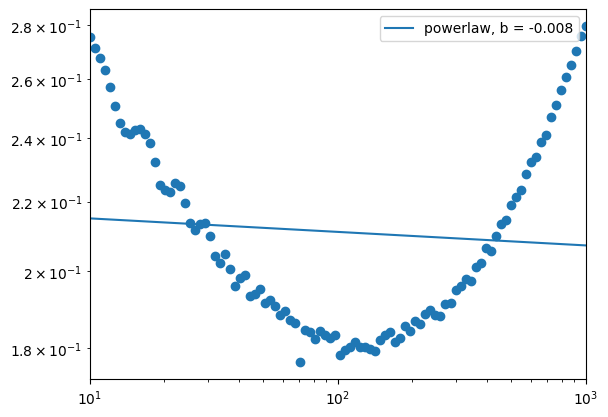

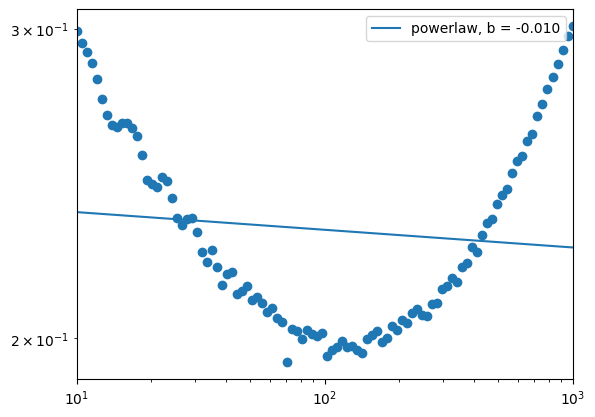

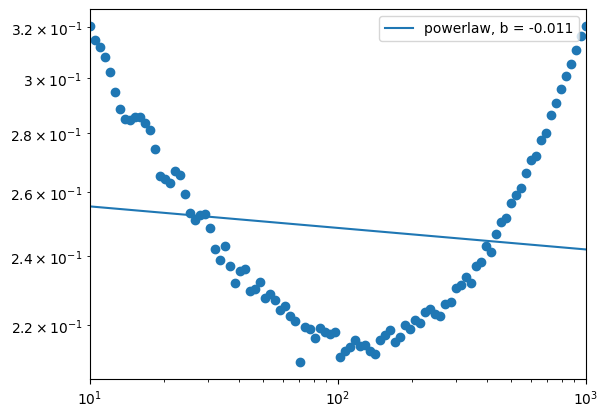

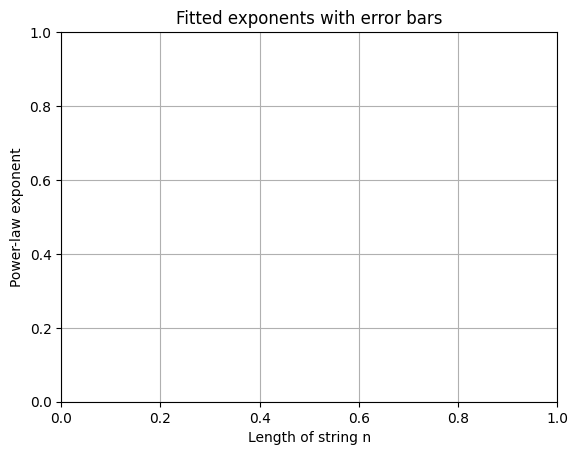

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def power_law(x, A, B):
    return A * x**B

def exp_law(x, A, B, C):
    return A * np.exp(-B * x) + C

def fit(dat, X):
    params_power_law, cov_power_law = curve_fit(power_law, X, dat)
    params_exp_law, cov_exp_law = curve_fit(exp_law, X, dat, maxfev=1000)

    plt.scatter(X, dat)
    plt.loglog(X, power_law(X, *params_power_law), label=f"powerlaw, b = {str(params_power_law[1])[:6]}")
    #plt.loglog(X, exp_law(X, *params_exp_law), label=f"exp law, b = {str(params_exp_law[1])[:5]}")
    plt.legend()
    plt.xlim(X[0], X[-1])
    plt.show()

    return params_power_law, cov_power_law

exponents=[]
errors = []

for i in range(1,10):
    params_power, cov_power = fit(x.T[:, i], taus)
    exponents.append(params_power[1])
    err = np.sqrt(cov_power[1]) if cov_power.ndim == 1 else np.sqrt(cov_power[1,1])
    errors.append(err)

exponents = np.array(exponents)
errors = np.array(errors)

plt.xlabel("Length of string n")
plt.ylabel("Power-law exponent")
plt.title("Fitted exponents with error bars")
plt.grid(True)
plt.show()


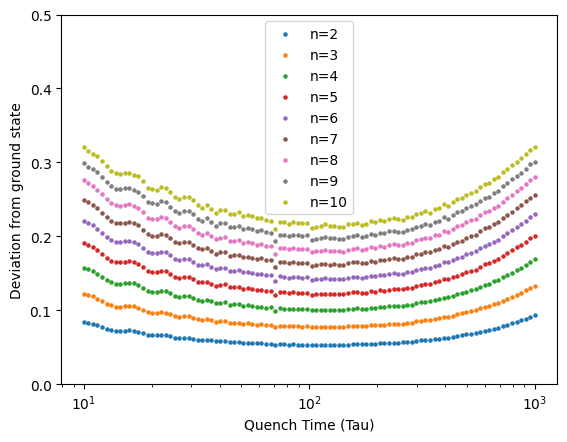

In [214]:

for i in range(1,10):
    plt.scatter(taus,np.abs(x.T[:, i]),label=f"n={i+1}",s=5)

#plt.yscale("log")
plt.xscale("log")
#plt.xlim(0.3,100)
plt.ylim(0,0.5)
plt.xlabel(f"Quench Time (Tau)")
plt.ylabel(f"Deviation from ground state")
plt.legend()
#plt.plot(taus,taus**(-1/2))

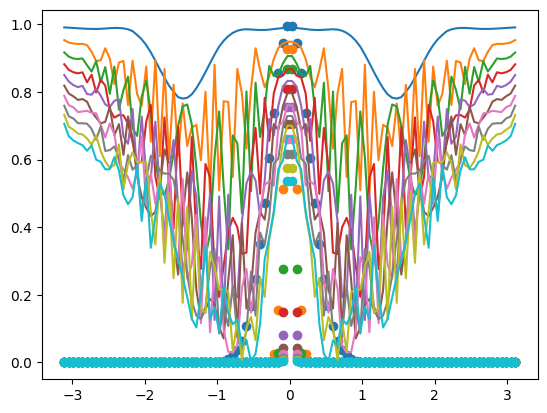

In [153]:
L =100
k=kb.k_vals(L)

from joblib import Parallel, delayed

def evolve_mode(i, v_0, k, t_span, t_eval, tau):
    v0 = [v_0[0][i] + 0j, v_0[1][i] + 0j]
    ki = k[i]
    res = solve_ivp(rhs, t_span, v0, args=(ki, tau), t_eval=t_eval)
    return res.y[0][-1], res.y[1][-1]
taus = np.linspace(1,100,10)
v_0 = kb.U(k,2)

T = 0
for tau in taus:
    results = Parallel(n_jobs=-1)(delayed(evolve_mode)(i, v_0, k, t_span, t_eval, tau) for i in range(len(k)))
    final_time_evolve = np.array(results).T
    T += 1
    plot(k,np.abs(final_time_evolve[0,:])**2)
    plt.scatter(k,np.exp(-2*np.pi*k**2*tau))

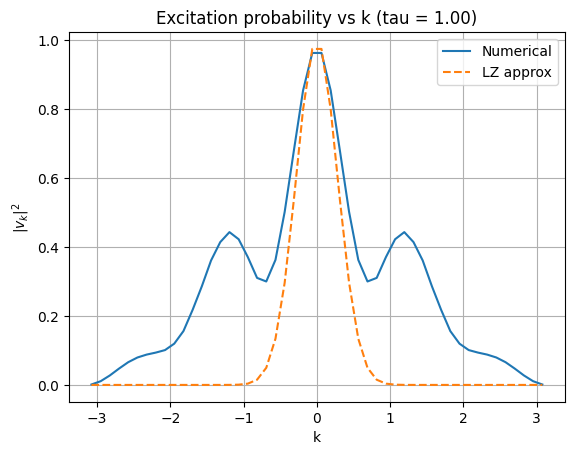

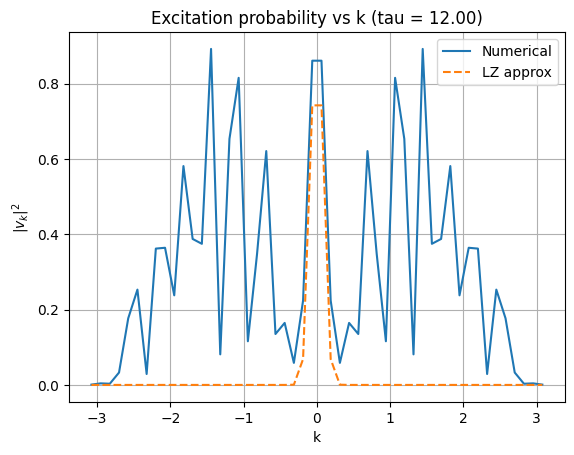

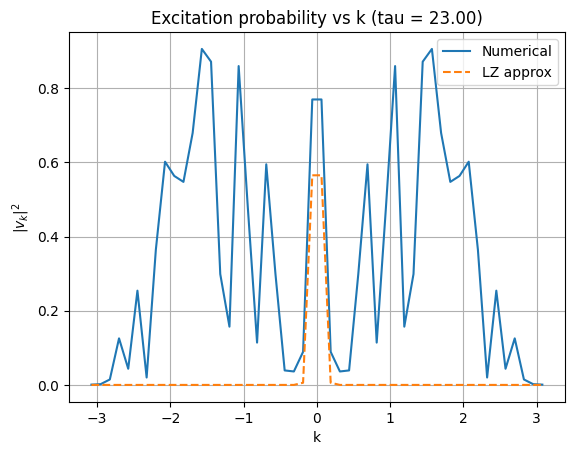

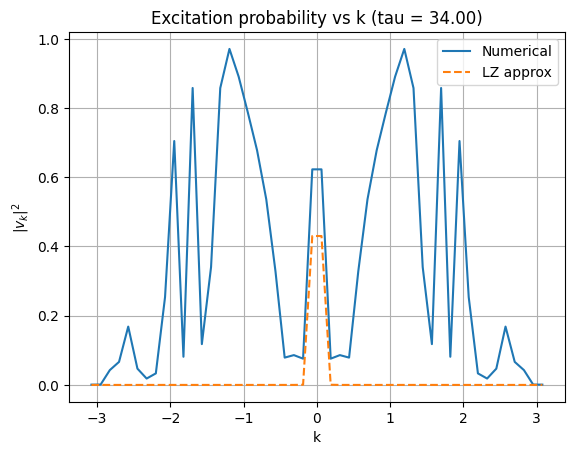

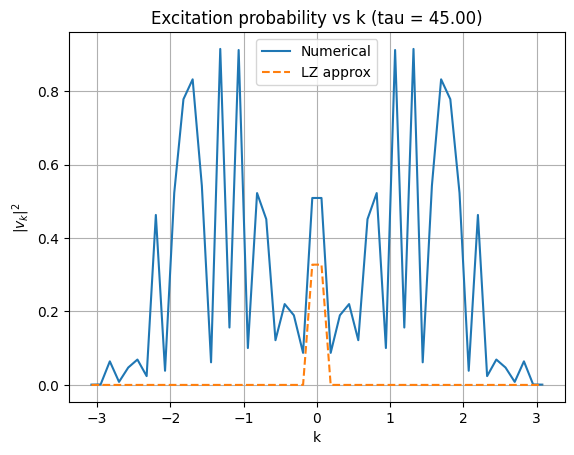

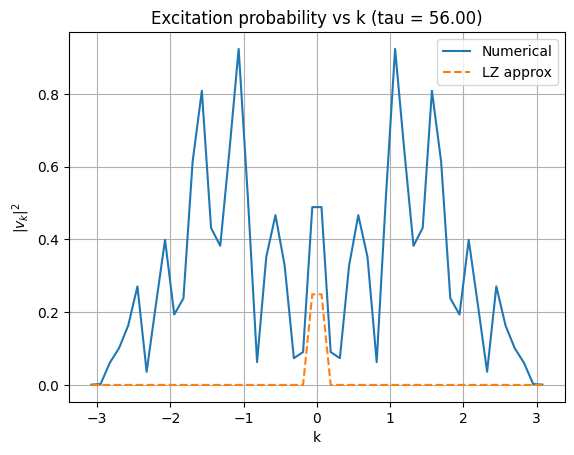

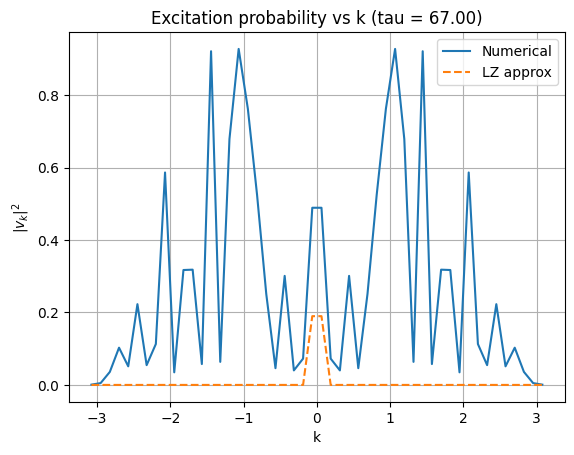

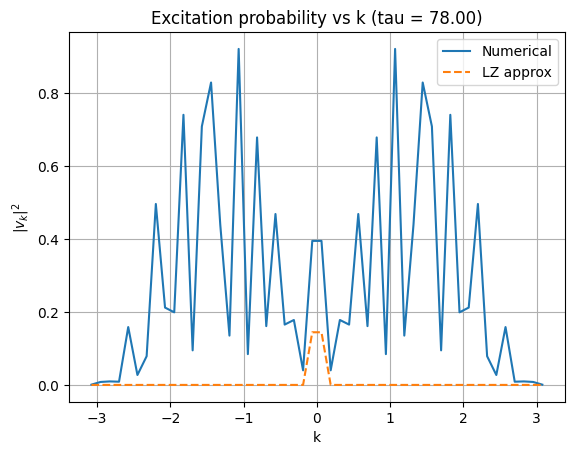

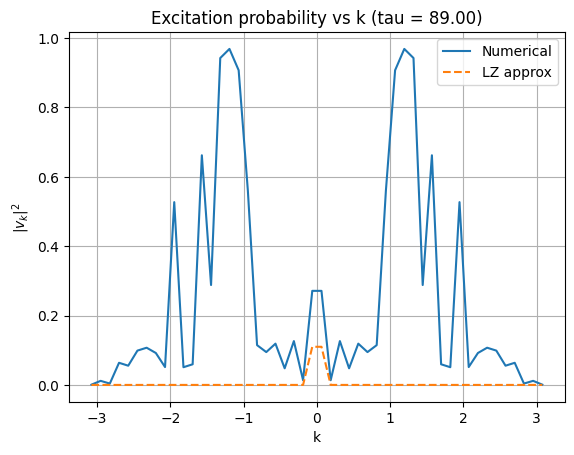

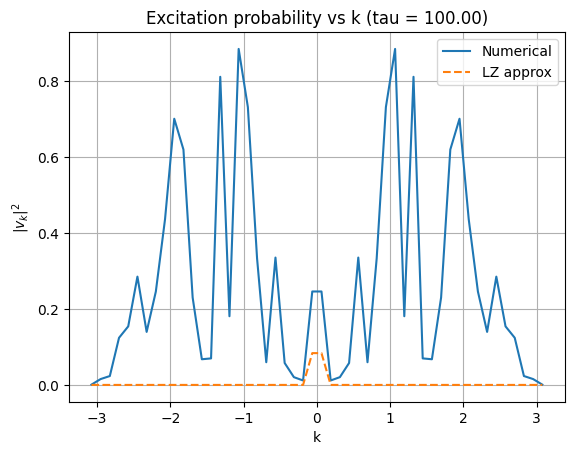

In [187]:
L = 50
k = kb.k_vals(L)
v_0 = kb.U(k, 0)
t_span = (0, 300)
t_eval = np.linspace(*t_span, 1000)
taus = np.linspace(1, 100, 10)

def evolve_mode(i, v_0, k, t_span, t_eval, tau):
    v0 = [v_0[0][i] + 0j, v_0[1][i] + 0j]
    ki = k[i]
    res = solve_ivp(rhs, t_span, v0, args=(ki, tau), t_eval=t_eval)
    return res.y[0][-1], res.y[1][-1]

for tau in taus:
    results = Parallel(n_jobs=-1)(delayed(evolve_mode)(i, v_0, k, t_span, t_eval, tau) for i in range(len(k)))
    final_time_evolve = np.array(results).T
    plt.figure()
    plt.plot(k, np.abs(final_time_evolve[1, :])**2, label="Numerical")
    plt.plot(k, np.exp(-2*np.pi * k**2 * tau), '--', label="LZ approx")
    plt.title(f"Excitation probability vs k (tau = {tau:.2f})")
    plt.xlabel("k")
    plt.ylabel(r"$|v_k|^2$")
    plt.legend()
    plt.grid(True)
    plt.show()


In [118]:
kb.U(k,0)

(array([0.99987663, 0.99888987, 0.99691733, 0.99396096, 0.99002366,
        0.98510933, 0.97922281, 0.97236992, 0.96455742, 0.95579301,
        0.94608536, 0.93544403, 0.92387953, 0.91140328, 0.89802758,
        0.88376563, 0.86863151, 0.85264016, 0.83580736, 0.81814972,
        0.79968466, 0.78043041, 0.76040597, 0.73963109, 0.7181263 ,
        0.6959128 , 0.67301251, 0.64944805, 0.62524266, 0.60042023,
        0.57500525, 0.54902282, 0.52249856, 0.49545867, 0.46792981,
        0.43993917, 0.41151436, 0.38268343, 0.35347484, 0.32391742,
        0.29404033, 0.26387305, 0.23344536, 0.2027873 , 0.1719291 ,
        0.14090123, 0.10973431, 0.0784591 , 0.04710645, 0.01570732,
        0.01570732, 0.04710645, 0.0784591 , 0.10973431, 0.14090123,
        0.1719291 , 0.2027873 , 0.23344536, 0.26387305, 0.29404033,
        0.32391742, 0.35347484, 0.38268343, 0.41151436, 0.43993917,
        0.46792981, 0.49545867, 0.52249856, 0.54902282, 0.57500525,
        0.60042023, 0.62524266, 0.64944805, 0.67